In [101]:
import pandas

In [102]:
dataset = pandas.read_csv('titanic_train.csv')

In [103]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [104]:
# Here y = Survived

dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [105]:
y = dataset['Survived']

In [106]:
dataset.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [107]:
X = dataset[[ 'Pclass', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Cabin', 'Embarked' ]]

In [108]:
# Feature will be that one only, which impacts the RESULT.
# Feature Engineering

X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,71.2833,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,NaN,S
887,1,female,19.0,0,0,30.0000,B42,S
888,3,female,NaN,1,2,23.4500,NaN,S
889,1,male,26.0,0,0,30.0000,C148,C


In [109]:
gender = dataset[ 'Sex' ]

In [110]:
# Dummy Variable. To remove the dummy variable trap we use drop_first=True

final_gender = pandas.get_dummies(gender, drop_first=True)

In [111]:
final_gender

,male
0,True
1,False
2,False
3,False
4,True
...,...
886,True
887,False
888,False
889,True


In [112]:
import seaborn as sns

<Axes: xlabel='Sex', ylabel='count'>

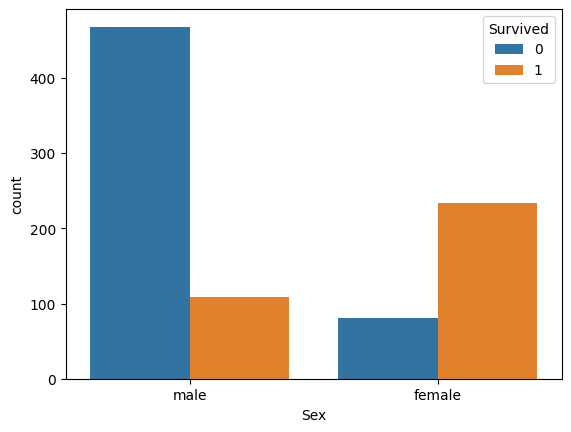

In [113]:
#  hue is used to find the surviving ratio
# This technique is called "Exploratory Data Analysis"

sns.countplot(x=gender , hue="Survived" , data=dataset)

In [114]:
Pclass = dataset[ 'Pclass' ]

<Axes: xlabel='Pclass', ylabel='count'>

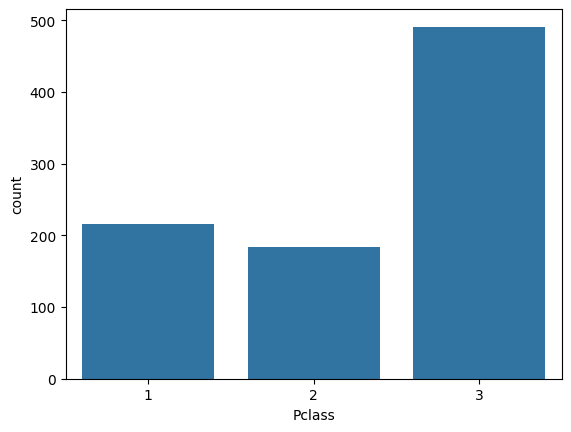

In [115]:
sns.countplot(x=Pclass)

<Axes: xlabel='Pclass', ylabel='count'>

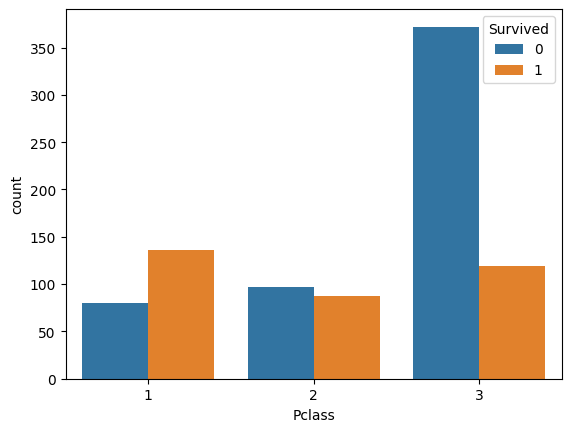

In [116]:
sns.countplot(x=Pclass, hue="Survived" , data=dataset)

In [117]:
# It is a categorical variable. So we need to make it a Dummy variable.

Pclass

0      3
1      1
2      3
3      1
4      3
      ..
886    2
887    1
888    3
889    1
890    3
Name: Pclass, Length: 891, dtype: int64

In [118]:
#   We are making it dummy variables.

pandas.get_dummies(Pclass)

,1,2,3
0,False,False,True
1,True,False,False
2,False,False,True
3,True,False,False
4,False,False,True
...,...,...,...
886,False,True,False
887,True,False,False
888,False,False,True
889,True,False,False


In [119]:
final_Pclass = pandas.get_dummies(Pclass, drop_first=True)

In [120]:
final_Pclass

,2,3
0,False,True
1,False,False
2,False,True
3,False,False
4,False,True
...,...,...
886,True,False
887,False,False
888,False,True
889,False,False


In [121]:
dataset[ 'Age' ]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [122]:
# We need to find out, how many NaN or Null is there in our Dataset

dataset.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

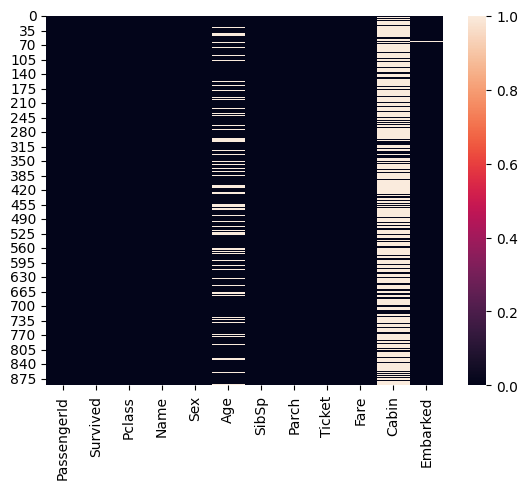

In [125]:
# white=null

sns.heatmap( dataset.isnull() )

In [126]:
# Here we have eliminated the feature 'cabin' after observing the above graph(sns.heatmap( dataset.isnull() ). Age has missing value.

X = dataset[[ 'Pclass', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Embarked' ]]

In [127]:
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [128]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S
887,1,female,19.0,0,0,30.0000,S
888,3,female,NaN,1,2,23.4500,S
889,1,male,26.0,0,0,30.0000,C


In [129]:
dataset['Pclass'] == 1

0      False
1       True
2      False
3       True
4      False
       ...  
886    False
887     True
888    False
889     True
890    False
Name: Pclass, Length: 891, dtype: bool

In [130]:
# Rows having True will only show. Here we are taking the average age of passengers from different classes. i,e Pclass = 1,2 3

age1 = int (dataset[ dataset['Pclass'] == 1]   ['Age'].mean() )

In [131]:
age1

38

In [132]:
age2 = int (dataset[ dataset['Pclass'] == 2]   ['Age'].mean() )

In [133]:
age2

29

In [134]:
age3 = int (dataset[ dataset['Pclass'] == 3]   ['Age'].mean() )

In [135]:
age3

25

In [136]:
import numpy

In [137]:
# if age is null then this statement will be true

numpy.isnan([])

array([], dtype=bool)

In [138]:
def ageMissing( d ):
    Pclass = d[0]
    age = d[1]

    if numpy.isnan(age):
        if Pclass == 1:
            return age1
        elif Pclass == 2:
            return age2
        elif Pclass == 3:
            return age3
        else:
            return 0

    else:
        return age

In [139]:
dataset[[ 'Pclass' , 'Age']].apply( ageMissing, axis=1 )

C:\Users\rahul\AppData\Local\Temp\ipykernel_2336\2094825952.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = d[0]
C:\Users\rahul\AppData\Local\Temp\ipykernel_2336\2094825952.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age = d[1]


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    25.0
889    26.0
890    32.0
Length: 891, dtype: float64

In [140]:
dataset[ 'Age' ] = dataset[[ 'Pclass' , 'Age']].apply( ageMissing , axis=1 )

C:\Users\rahul\AppData\Local\Temp\ipykernel_2336\2094825952.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = d[0]
C:\Users\rahul\AppData\Local\Temp\ipykernel_2336\2094825952.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age = d[1]


In [141]:
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,25.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


<Axes: >

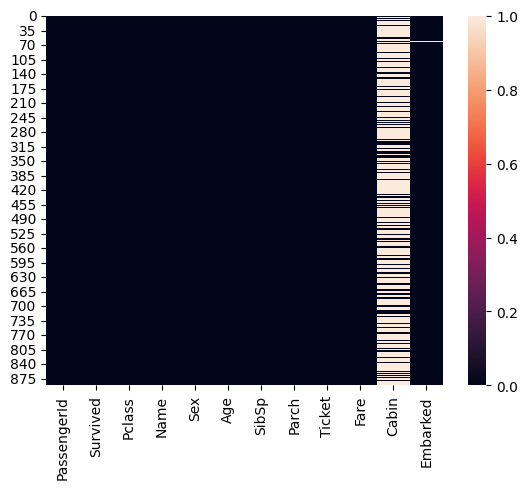

In [142]:
# Here Age column is completely blue

sns.heatmap( dataset.isnull() )

<Axes: xlabel='SibSp', ylabel='count'>

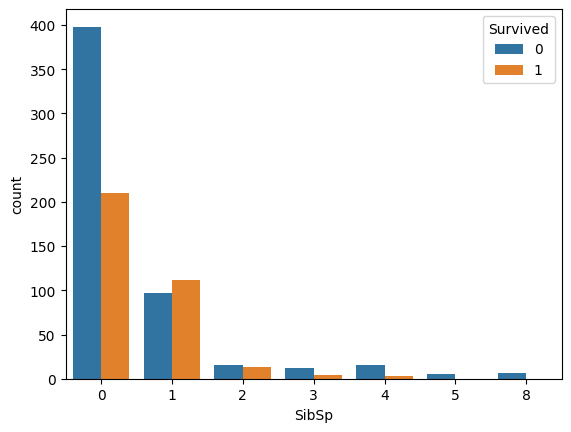

In [143]:
sns.countplot( x=dataset[ 'SibSp' ], hue='Survived' , data=dataset)

<Axes: xlabel='Parch', ylabel='count'>

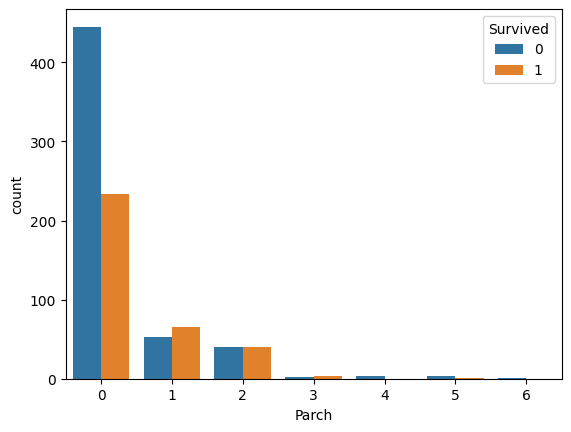

In [144]:
sns.countplot( x=dataset[ 'Parch' ], hue='Survived' , data=dataset)

In [145]:
# Here we can eliminate Feature 'Parch' & 'SibSp'
# Here we can eliminate the feature 'Fare'. Because Fare is directly proportional to Pclass.

In [146]:
dataset.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [147]:
dataset[  [  'Pclass' , 'Sex' , 'Age' ]  ]

,Pclass,Sex,Age
0,3,male,22.0
1,1,female,38.0
2,3,female,26.0
3,1,female,35.0
4,3,male,35.0
...,...,...,...
886,2,male,27.0
887,1,female,19.0
888,3,female,25.0
889,1,male,26.0


In [148]:
#   concat is used to add different columns in a single data.

X = pandas.concat( [  dataset['Age'] , final_Pclass , final_gender], axis=1  )

In [149]:
y = dataset[ 'Survived' ]

In [150]:
X

,Age,2,3,male
0,22.0,False,True,True
1,38.0,False,False,False
2,26.0,False,True,False
3,35.0,False,False,False
4,35.0,False,True,True
...,...,...,...,...
886,27.0,True,False,True
887,19.0,False,False,False
888,25.0,False,True,False
889,26.0,False,False,True


In [151]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [152]:
from sklearn.linear_model import LogisticRegression

In [153]:
X.columns

Index(['Age', 2, 3, 'male'], dtype='object')

In [154]:
#  Here columns are combination if String & Integer. So, we have to convert Integer to String.

In [155]:
X.columns = X.columns.astype(str)

In [156]:
X.columns

Index(['Age', '2', '3', 'male'], dtype='object')

In [157]:
model = LogisticRegression()

In [158]:
model.fit(X, y)

LogisticRegression()

In [159]:
model.coef_

array([[-0.03370409, -1.02961305, -2.26183852, -2.4898238 ]])

In [160]:
model.predict(X)

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,

In [161]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [162]:
dataset_test = pandas.read_csv( 'titanic_test.csv' )

In [163]:
dataset_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [164]:
final_gender = pandas.get_dummies(gender, drop_first=True)
final_Pclass = pandas.get_dummies(Pclass, drop_first=True)
dataset_test[ 'Age' ] = dataset_test[[ 'Pclass' , 'Age']].apply( ageMissing , axis=1 )
X_test = pandas.concat( [  dataset_test['Age'] , final_Pclass , final_gender], axis=1  )

C:\Users\rahul\AppData\Local\Temp\ipykernel_2336\2094825952.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = d[0]
C:\Users\rahul\AppData\Local\Temp\ipykernel_2336\2094825952.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age = d[1]


In [165]:
X_test

,Age,2,3,male
0,34.5,False,True,True
1,47.0,False,False,False
2,62.0,False,True,False
3,27.0,False,False,False
4,22.0,False,True,True
...,...,...,...,...
886,NaN,True,False,True
887,NaN,False,False,False
888,NaN,False,True,False
889,NaN,False,False,True


In [166]:
X_test.columns = X_test.columns.astype(str)

In [167]:
X_test.columns

Index(['Age', '2', '3', 'male'], dtype='object')

In [168]:
dataset_confusionmetrix = pandas.concat( [  X , y ] , axis=1  )

In [169]:
dataset_confusionmetrix

,Age,2,3,male,Survived
0,22.0,False,True,True,0
1,38.0,False,False,False,1
2,26.0,False,True,False,1
3,35.0,False,False,False,1
4,35.0,False,True,True,0
...,...,...,...,...,...
886,27.0,True,False,True,0
887,19.0,False,False,False,1
888,25.0,False,True,False,0
889,26.0,False,False,True,1


In [170]:
dataset_confusionmetrix.columns = dataset_confusionmetrix.columns.astype(str)

In [171]:
dataset_confusionmetrix

,Age,2,3,male,Survived
0,22.0,False,True,True,0
1,38.0,False,False,False,1
2,26.0,False,True,False,1
3,35.0,False,False,False,1
4,35.0,False,True,True,0
...,...,...,...,...,...
886,27.0,True,False,True,0
887,19.0,False,False,False,1
888,25.0,False,True,False,0
889,26.0,False,False,True,1


In [172]:
dataset_confusionmetrix.columns

Index(['Age', '2', '3', 'male', 'Survived'], dtype='object')

In [173]:
y = dataset_confusionmetrix[  'Survived'  ]

In [174]:
X = dataset_confusionmetrix[ [ 'Age', '2' , '3' , 'male'  ]   ]

In [175]:
X

,Age,2,3,male
0,22.0,False,True,True
1,38.0,False,False,False
2,26.0,False,True,False
3,35.0,False,False,False
4,35.0,False,True,True
...,...,...,...,...
886,27.0,True,False,True
887,19.0,False,False,False
888,25.0,False,True,False
889,26.0,False,False,True


In [176]:
from sklearn.model_selection import train_test_split

In [177]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [178]:
from sklearn.linear_model import LogisticRegression

In [179]:
model_confusionmatrix = LogisticRegression()

In [183]:
model_confusionmatrix.fit(X_train, y_train)

LogisticRegression()

In [184]:
from sklearn.metrics import confusion_matrix

In [186]:
y_test

709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64

In [188]:
y_pred = model_confusionmatrix.predict(  X_test  )

In [189]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1], dtype=int64)

In [190]:
confusion_matrix(y_test , y_pred)

array([[92, 13],
       [22, 52]], dtype=int64)